# Initial-shock anomaly errors: RMSE and MAE

Archive-backed companion to `6a_initial_shock_std_index.ipynb`.

**Configure → inventory and cache plan → reuse/prepare common-grid global indices →
full-cohort anomaly calculation → cached RMSE/MAE → case comparisons.**

This applies the metrics in `Compute_RMSE_With_MAE_Index_share.ncl` to the E3SM
and CESM-SMYLE archives: ensemble mean, consecutive monthly blocks, area-weighted
global indices, independent model/observation climatologies, then raw and
climatologically normalized RMSE and MAE.


In [25]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

repo_root = next((p for p in (Path.cwd(), Path.cwd().parent) if (p / 'esp_lab').is_dir()), None)
if repo_root is not None:
    sys.path.insert(0, str(repo_root))
from importlib import reload
from esp_lab.diagnostics import initial_shock_error as initial_shock_error_diagnostic
initial_shock_error_diagnostic = reload(initial_shock_error_diagnostic)
plot_error_heatmap = initial_shock_error_diagnostic.plot_error_heatmap
from workflows.diagnostics import initial_shock_error_archive as initial_shock_error_archive_workflow
initial_shock_error_archive_workflow = reload(initial_shock_error_archive_workflow)
plan_archive_run = initial_shock_error_archive_workflow.plan_archive_run
compute_archive_plan = initial_shock_error_archive_workflow.compute_archive_plan
from esp_lab.utils.dask_util import DaskConfig, get_cluster_client
from esp_lab.utils.resource_utils import ResourceTracker


## User setup and workflow configuration

Select a field and E3SM cases as in `6a`. Input discovery, unit conversion,
verification-time checks, conservative regridding, and ensemble completeness checks
are shared with that workflow. `TREFHT` matches the NCL example.

The NCL script uses five annual samples. The current archive provides 24 months, so
the defaults apply the same RMSE/MAE definitions to two consecutive 12-month blocks.
May blocks are May–April and November blocks are November–October. Primary heatmaps
normalize errors by the observed first-block interannual standard deviation over the
configured climatology period. Set
their color boundaries explicitly in `ERROR_HEATMAP_LEVELS`. Raw RMSE and MAE remain
available in the comparison tables for continuity with the NCL diagnostic.


In [26]:
VAR_CONFIG = {
    'TREFHT': dict(obs_product='ERA5', obs_variable='tas', units='degC',
                   model_scale=1., model_offset=-273.15, smyle_scale=1., smyle_offset=-273.15,
                   obs_scale=1., obs_offset=-273.15),
    'TS': dict(obs_product='ERA5', obs_variable='ts', units='degC',
               model_scale=1., model_offset=-273.15, smyle_scale=1., smyle_offset=-273.15,
               obs_scale=1., obs_offset=-273.15),
    'PRECT': dict(obs_product='GPCP_v2.3', obs_variable='PRECT', units='mm/day',
                  model_scale=86400000., model_offset=0., smyle_scale=86400000., smyle_offset=0.,
                  obs_scale=1., obs_offset=0.),
    'PSL': dict(obs_product='ERA5', obs_variable='psl', units='hPa',
                model_scale=.01, model_offset=0., smyle_scale=.01, smyle_offset=0.,
                obs_scale=.01, obs_offset=0.),
}
field = 'TREFHT'
variable = dict(VAR_CONFIG[field], field=field, model_variable=field, smyle_variable=field)

# Explicit color-bin boundaries for the primary normalized-error heatmaps.
ERROR_HEATMAP_LEVELS = {
    'normalized_rmse': np.arange(0.0, 2.0 + 0.2, 0.2),
    'normalized_mae': np.arange(0.0, 2.0 + 0.2, 0.2),
}
PLOT_INITIALIZATION_INSPECTION = False

E3SM_CASES = {
    'E3SM-FOSIRL': dict(case_prefix='WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL', cache_tag='JRA55_FOSIRL'),
    'E3SM-Reanalysis': dict(case_prefix='WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce', cache_tag='Reanalysis'),
    'E3SM-4DEnVarOcn': dict(case_prefix='WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_4DEnVarOcn', cache_tag='4DEnVarOcn'),
}
# Optional common processing end year. None uses the full period.
YEAR_END = 2011  # None

WORKFLOW_SETTINGS = {
    'paths': {
        's2d_diag_root': '/global/cfs/cdirs/e3sm/S2S2D/s2d_diag',
        'figure_outdir': '/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/initial_shock_rmse_mae',
    },
    'run': {'initialization_years': (1980, 2018 if YEAR_END is None else int(YEAR_END)), 'year_end': YEAR_END,
            'years': [1980, 2018 if YEAR_END is None else int(YEAR_END)],
            'init_months': [5, 11], 'nlead': 24, 'smoke_mode': False},
    'e3sm': {
        'data_dir': '/global/cfs/cdirs/e3sm/S2S2D/post_process',
        'nens': 10, 'grid': '180x360_aave', 'ts_split': '2yr', 'engine': 'netcdf4',
        'chunks': {'Y': 3, 'L': 24, 'M': 2, 'lat': 90, 'lon': 180},
    },
    'smyle': {
        'include': True, 'nens': 20,
        'benchmark_dir': '/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE',
        'chunks': {'Y': 3, 'L': 24, 'M': 2, 'lat': 96, 'lon': 144},
    },
    'obs': {
        'data_dir': '/global/cfs/cdirs/e3sm/e3sm_diags/obs_for_e3sm_diags/time-series',
        'chunks': {'time': 24, 'lat': 90, 'lon': 180},
    },
    'regrid': {'target_dlat': 1., 'target_dlon': 1., 'method': 'conservative', 'periodic': True},
    'metric': {'window_months': 24, 'block_months': 12, 'start_lead': 0,
               'min_samples': None, 'min_area_fraction': .9,
               'climatology_years': [1981, 2010]},
    'cache': {'mode': 'auto', 'force_compute': False},  # set force_compute=True to refresh valid caches
    'dask': {'enabled': True, 'workers': 8},
}
if WORKFLOW_SETTINGS['run']['smoke_mode']:
    E3SM_CASES = {'E3SM-FOSIRL': E3SM_CASES['E3SM-FOSIRL']}
    WORKFLOW_SETTINGS['run'].update(years=[1980, 1981], init_months=[11])
    WORKFLOW_SETTINGS['regrid'].update(target_dlat=5., target_dlon=5.)
    WORKFLOW_SETTINGS['dask']['workers'] = 2
    print('Archive-backed smoke mode: one E3SM case, CESM-SMYLE, two starts, one month.')
if 'E3SM-4DEnVarOcn' in E3SM_CASES and WORKFLOW_SETTINGS['run']['years'][1] > 2011:
    raise ValueError(
        f"E3SM-4DEnVarOcn only spans 1980-2011. For multi-model comparison with 4DEnVar, "
        f"set YEAR_END = 2011 or remove 'E3SM-4DEnVarOcn' from E3SM_CASES."
    )
print('Field:', field, '| Years:', WORKFLOW_SETTINGS['run']['years'])
print('Metric:', WORKFLOW_SETTINGS['metric'])


Field: TREFHT | Years: [1980, 2011]
Metric: {'window_months': 24, 'block_months': 12, 'start_lead': 0, 'min_samples': None, 'min_area_fraction': 0.9, 'climatology_years': [1981, 2010]}


## Inventory and cache plan

Inventory all requested initializations before expensive processing. All E3SM members
and requested starts are required. The plan identifies both the shared compact block-
index cache and the derived RMSE/MAE cache. Cache identity covers source inventories,
settings, adapters, and both algorithms. `require` opens compatible caches only;
`force_compute=True` refreshes the selected caches at their existing paths.


In [27]:
archive_plan = plan_archive_run(WORKFLOW_SETTINGS, E3SM_CASES, variable)
plan_table = pd.DataFrame([
    {'case': t['case'], 'init_month': t['month'], 'initializations': len(t['years']),
     'source_files': len(t['inventory']),
     'block_indices': 'prepare' if t['rebuild'] else 'reuse',
     'rmse_mae': 'prepare' if t['error_rebuild'] else 'reuse',
     'cache': t['error_path']}
    for t in archive_plan
])
display(plan_table)


,case,init_month,initializations,source_files,block_indices,rmse_mae,cache
0,E3SM-FOSIRL,5,32,321,reuse,reuse,/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FO...
1,E3SM-Reanalysis,5,32,321,reuse,reuse,/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalys...
2,E3SM-4DEnVarOcn,5,32,321,reuse,reuse,/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/4DEnVarO...
3,CESM-SMYLE,5,32,2,reuse,reuse,/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMY...
4,E3SM-FOSIRL,11,32,321,reuse,reuse,/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FO...
5,E3SM-Reanalysis,11,32,321,reuse,reuse,/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalys...
6,E3SM-4DEnVarOcn,11,32,321,reuse,reuse,/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/4DEnVarO...
7,CESM-SMYLE,11,32,2,reuse,reuse,/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMY...


## Dask resources

Start after the inventory succeeds. Rerunning this cell closes the previous cluster.
Run the cleanup cell when finished, including after an interrupted computation.


In [28]:
from esp_lab.utils.notebook_resources import restart_notebook_cluster, close_notebook_resources

cluster, client, workflow_resources = restart_notebook_cluster(
    globals(),
    lambda: get_cluster_client(DaskConfig(
        cluster_type='local', workers=WORKFLOW_SETTINGS['dask']['workers']))
        if WORKFLOW_SETTINGS['dask']['enabled'] else (None, None),
)
if client is not None:
    display(client)



!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
This can easily exceed memory/CPU limits and crash your Jupyter kernel.
We highly recommend launching Jupyter on an Exclusive Perlmutter Compute Node.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 37453 instead
  warnings.warn(


Scheduler: tcp://127.0.0.1:45147
Connected workers: 4
Dashboard: http://127.0.0.1:37453/status


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:37453/status,
Dashboard: http://127.0.0.1:37453/status,Workers: 4
Total threads: 4,Total memory: 14.90 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45147,Workers: 0
Dashboard: http://127.0.0.1:37453/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33431,Total threads: 1
Dashboard: http://127.0.0.1:33333/status,Memory: 3.73 GiB
Nanny: tcp://127.0.0.1:46675,


## Common-grid indices, anomaly metrics, and cache writing

The workflow reuses the compact global block indices from `6a` when compatible. If
needed, it opens the monthly archives, verifies represented months, converts units,
regrids model and observations, averages members and monthly blocks, and computes
area-weighted global indices.

For each case and initialization month, model and observation indices are centered on
their own means over the complete requested `Y × block` cohort, following the NCL
climatology construction. RMSE and MAE are then reduced over paired blocks within each
initialization. RMSE and MAE are also divided by the observed climatological standard
deviation used by `6a`. Derived caches retain raw and normalized errors, anomalies,
sample counts, and provenance.


In [29]:
comparison_by_month = compute_archive_plan(archive_plan, WORKFLOW_SETTINGS, variable)
for month, comparison in comparison_by_month.items():
    print(f'Initialization month {month:02d}')
    display(comparison[['normalized_rmse', 'normalized_mae', 'rmse', 'mae',
                        'observation_climatology_std',
                        'paired_sample_count', 'valid_metric']])
    display(comparison[['model_climatology', 'observation_climatology']])


Reusing E3SM-FOSIRL init 05: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/initial_shock/metrics/atm/TREFHT/init05_7c4afbf7e3e109ed353e.nc
Reusing E3SM-Reanalysis init 05: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalysis/initial_shock/metrics/atm/TREFHT/init05_8870053374ebca10e031.nc
Reusing E3SM-4DEnVarOcn init 05: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/4DEnVarOcn/initial_shock/metrics/atm/TREFHT/init05_eb2eb8b973f13ffaedd1.nc
Reusing CESM-SMYLE init 05: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/initial_shock/metrics/atm/TREFHT/init05_77ab0584e6b2bfb1e086.nc
Reusing E3SM-FOSIRL init 11: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/initial_shock/metrics/atm/TREFHT/init11_03aad61764b313b3b0a7.nc
Reusing E3SM-Reanalysis init 11: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalysis/initial_shock/metrics/atm/TREFHT/init11_1d1f750512f9418fa269.nc
Reusing E3SM-4DEnVarOcn init 11: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/4DEnVarOcn/initial_shock/metrics/atm/TREFHT/init11_74760afb9a4

<xarray.Dataset> Size: 6kB
Dimensions:                      (case: 4, Y: 32)
Coordinates:
  * case                         (case) object 32B 'E3SM-FOSIRL' ... 'CESM-SM...
  * Y                            (Y) int64 256B 1980 1981 1982 ... 2010 2011
    height                       float64 8B 2.0
Data variables:
    normalized_rmse              (case, Y) float64 1kB 0.6165 0.8351 ... 0.154
    normalized_mae               (case, Y) float64 1kB 0.4493 0.8335 ... 0.1129
    rmse                         (case, Y) float64 1kB 0.1118 0.1515 ... 0.02793
    mae                          (case, Y) float64 1kB 0.08148 ... 0.02047
    observation_climatology_std  (case) float64 32B 0.1814 0.1814 0.1814 0.1814
    paired_sample_count          (case, Y) int64 1kB 2 2 2 2 2 2 ... 2 2 2 2 2 2
    valid_metric                 (case, Y) int8 128B 1 1 1 1 1 1 ... 1 1 1 1 1 1
Attributes:
    diagnostic_version:            initial_shock_rmse_mae_v2
    min_samples:                   2
    anomaly_baseline:              independent model and observation means ov...
    error_reduction:               paired blocks within each initialization; ...
    interpretation:                Error amplitude after removing each series...
    normalized_error_denominator:  sample std of observed first-block annual ...
    field:                         TREFHT
    init_month:                    5

<xarray.Dataset> Size: 104B
Dimensions:                  (case: 4)
Coordinates:
  * case                     (case) object 32B 'E3SM-FOSIRL' ... 'CESM-SMYLE'
    height                   float64 8B 2.0
Data variables:
    model_climatology        (case) float64 32B 14.18 14.26 14.29 14.53
    observation_climatology  (case) float64 32B 14.19 14.19 14.19 14.19
Attributes:
    diagnostic_version:            initial_shock_rmse_mae_v2
    min_samples:                   2
    anomaly_baseline:              independent model and observation means ov...
    error_reduction:               paired blocks within each initialization; ...
    interpretation:                Error amplitude after removing each series...
    normalized_error_denominator:  sample std of observed first-block annual ...
    field:                         TREFHT
    init_month:                    5

Initialization month 11


<xarray.Dataset> Size: 6kB
Dimensions:                      (case: 4, Y: 32)
Coordinates:
  * case                         (case) object 32B 'E3SM-FOSIRL' ... 'CESM-SM...
  * Y                            (Y) int64 256B 1980 1981 1982 ... 2010 2011
    height                       float64 8B 2.0
Data variables:
    normalized_rmse              (case, Y) float64 1kB 0.1974 0.9999 ... 0.1119
    normalized_mae               (case, Y) float64 1kB 0.1602 0.9747 ... 0.09416
    rmse                         (case, Y) float64 1kB 0.03736 ... 0.02117
    mae                          (case, Y) float64 1kB 0.03031 ... 0.01782
    observation_climatology_std  (case) float64 32B 0.1893 0.1893 0.1893 0.1893
    paired_sample_count          (case, Y) int64 1kB 2 2 2 2 2 2 ... 2 2 2 2 2 2
    valid_metric                 (case, Y) int8 128B 1 1 1 1 1 1 ... 1 1 1 1 1 1
Attributes:
    diagnostic_version:            initial_shock_rmse_mae_v2
    min_samples:                   2
    anomaly_baseline:              independent model and observation means ov...
    error_reduction:               paired blocks within each initialization; ...
    interpretation:                Error amplitude after removing each series...
    normalized_error_denominator:  sample std of observed first-block annual ...
    field:                         TREFHT
    init_month:                    11

<xarray.Dataset> Size: 104B
Dimensions:                  (case: 4)
Coordinates:
  * case                     (case) object 32B 'E3SM-FOSIRL' ... 'CESM-SMYLE'
    height                   float64 8B 2.0
Data variables:
    model_climatology        (case) float64 32B 14.22 14.29 14.3 14.64
    observation_climatology  (case) float64 32B 14.2 14.2 14.2 14.2
Attributes:
    diagnostic_version:            initial_shock_rmse_mae_v2
    min_samples:                   2
    anomaly_baseline:              independent model and observation means ov...
    error_reduction:               paired blocks within each initialization; ...
    interpretation:                Error amplitude after removing each series...
    normalized_error_denominator:  sample std of observed first-block annual ...
    field:                         TREFHT
    init_month:                    11

## Comparison tables and normalized-error heatmaps

Lower values indicate closer anomaly evolution. Missing cells fail the configured
paired-block requirement. One figure compares May and November starts in separate
columns, with normalized RMSE and normalized MAE in separate rows. Rows within each
heatmap are initialization years and columns are experiments.


,case,Y,normalized_rmse,normalized_mae,rmse,mae,observation_climatology_std,paired_sample_count,valid_metric,height
0,E3SM-FOSIRL,1980,0.616463,0.449285,0.111797,0.081479,0.181352,2,1,2.0
1,E3SM-FOSIRL,1981,0.835124,0.833505,0.151452,0.151158,0.181352,2,1,2.0
2,E3SM-FOSIRL,1982,0.647816,0.536803,0.117483,0.097350,0.181352,2,1,2.0
3,E3SM-FOSIRL,1983,0.596788,0.595439,0.108229,0.107984,0.181352,2,1,2.0
4,E3SM-FOSIRL,1984,0.788004,0.588237,0.142906,0.106678,0.181352,2,1,2.0
...,...,...,...,...,...,...,...,...,...,...
123,CESM-SMYLE,2007,0.034182,0.025716,0.006199,0.004664,0.181352,2,1,2.0
124,CESM-SMYLE,2008,0.469669,0.427081,0.085175,0.077452,0.181352,2,1,2.0
125,CESM-SMYLE,2009,0.576042,0.573123,0.104467,0.103937,0.181352,2,1,2.0
126,CESM-SMYLE,2010,0.098731,0.089376,0.017905,0.016209,0.181352,2,1,2.0


,case,Y,normalized_rmse,normalized_mae,rmse,mae,observation_climatology_std,paired_sample_count,valid_metric,height
0,E3SM-FOSIRL,1980,0.197417,0.160152,0.037362,0.030309,0.189253,2,1,2.0
1,E3SM-FOSIRL,1981,0.999883,0.974655,0.189231,0.184457,0.189253,2,1,2.0
2,E3SM-FOSIRL,1982,0.561596,0.397459,0.106284,0.075220,0.189253,2,1,2.0
3,E3SM-FOSIRL,1983,0.536325,0.385325,0.101501,0.072924,0.189253,2,1,2.0
4,E3SM-FOSIRL,1984,0.890550,0.684010,0.168539,0.129451,0.189253,2,1,2.0
...,...,...,...,...,...,...,...,...,...,...
123,CESM-SMYLE,2007,0.477144,0.450950,0.090301,0.085344,0.189253,2,1,2.0
124,CESM-SMYLE,2008,0.709555,0.587189,0.134286,0.111127,0.189253,2,1,2.0
125,CESM-SMYLE,2009,0.064120,0.051642,0.012135,0.009773,0.189253,2,1,2.0
126,CESM-SMYLE,2010,0.127772,0.123662,0.024181,0.023403,0.189253,2,1,2.0


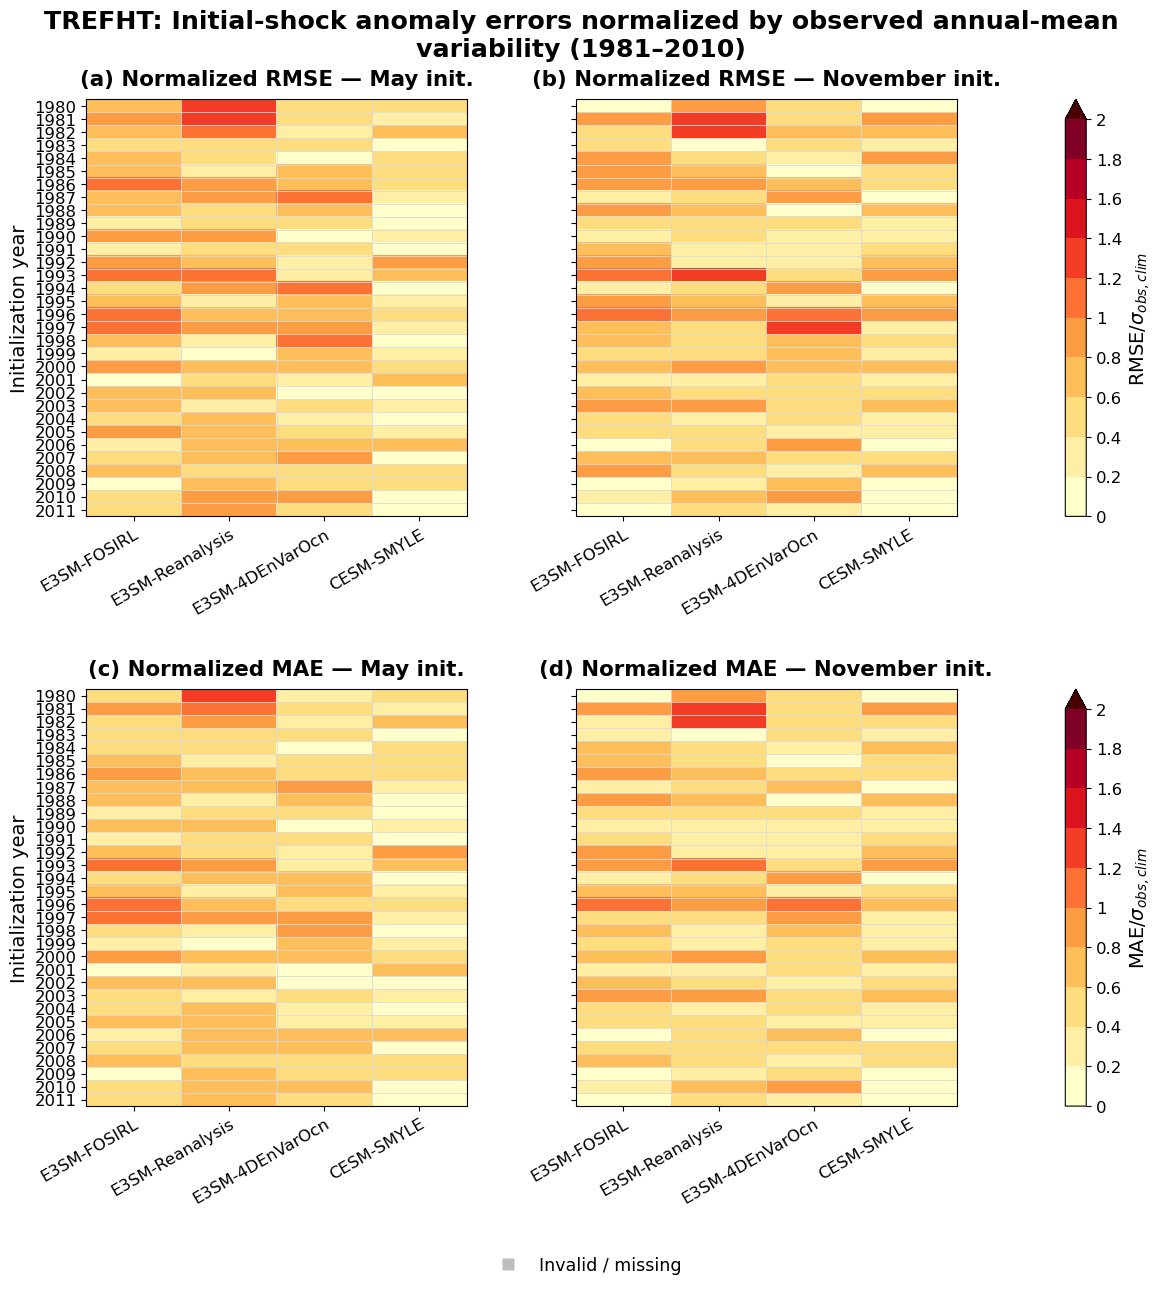

Saved normalized-error comparison: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/initial_shock_rmse_mae/TREFHT_init05-init11_normalized_rmse_mae.png


In [30]:
# =============================================================================
# Plot Setup and Style Parameters
# =============================================================================
# Text
figure_title_template = (
    '{field}: Model–observation global-mean anomaly errors\n'
    'normalized by observed first-year interannual variability ({climatology_label})'
)
panel_title_template = '({panel_label}) {metric_title} — {month_label} init.'
unknown_month_template = 'Month {month:02d}'
y_axis_label = 'Initialization year'
invalid_label = 'Invalid / missing'

# Master font size control for the multi-panel figure; all components scale from fontz
fontz = 14
panel_title_size = fontz * 1.10     # Subplot panel titles (~15.4 pt)
axis_label_size = fontz * 1.00      # Axis labels (Y-axis "Initialization year") (~14.0 pt)
tick_label_size = fontz * 0.85      # Tick mark labels (years, case names) (~11.9 pt)
colorbar_label_size = fontz * 1.00  # Colorbar label font size (~14.0 pt)
colorbar_tick_size = fontz * 0.85   # Colorbar tick values font size (~11.9 pt)
suptitle_size = fontz * 1.30        # Main super title font size (~18.2 pt)
legend_size = fontz * 0.90          # Legend font size (~12.6 pt)
fweight = 'bold'
panel_title_pad = 10

# Explicit color bar levels and tick marks
colorbar_levels = {
    'normalized_rmse': np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]),
    'normalized_mae':  np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]),
}
colorbar_ticks = {
    'normalized_rmse': [0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0],
    'normalized_mae':  [0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0],
}

# Panel definitions and month mappings
month_names = {5: 'May', 11: 'November'}
error_plot_specs = [
    ('normalized_rmse', 'Normalized RMSE', r'$\mathrm{RMSE} / \sigma_{obs,clim}$'),
    ('normalized_mae', 'Normalized MAE', r'$\mathrm{MAE} / \sigma_{obs,clim}$'),
]

# Layout, figure sizing, and file output
fig_col_width = 4.0
fig_row_height_scale = 0.4  # Height scaling per initialization year
min_fig_height = 12
dpi = 300
figfmt = 'png'

# X-axis label controls (show case names on all rows to clearly identify columns)
show_x_labels_all_rows = True
x_tick_rotation = 30
x_tick_horizontal_alignment = 'right'
x_tick_rotation_mode = 'anchor'

# Grid geometry. Colorbars and the legend get their own cells so they cannot
# resize or overlap the heatmap axes as panel counts and label lengths change.
cbar_width_ratio = 0.055
heatmap_width_ratio = 1.0
legend_height_ratio = 0.045
heatmap_height_ratio = 1.0
grid_wspace = 0.08
grid_hspace = 0.10
cbar_extend = 'max'
layout_engine = 'constrained'
min_fig_width = 11.5
cbar_extra_width = 0.65

# Invalid/missing-data legend
invalid_marker = 's'
invalid_marker_size = 9
invalid_marker_edgecolor = 'none'
legend_location = 'center'
legend_frameon = False

# Tabular and figure output
summary_variables = [
    'normalized_rmse', 'normalized_mae', 'rmse', 'mae',
    'observation_climatology_std', 'paired_sample_count', 'valid_metric',
]
summary_filename_template = '{field}_init{month:02d}_rmse_mae_summary.csv'
figure_filename_template = '{field}_{month_token}_normalized_rmse_mae.{figfmt}'
save_bbox_inches = 'tight'
save_pad_inches = 0.08

# =============================================================================
# Export Summary Tables & Generate Comparison Figure
# =============================================================================
FIGURE_ROOT = Path(WORKFLOW_SETTINGS['paths']['figure_outdir'])
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
for month, comparison in comparison_by_month.items():
    summary = comparison[summary_variables].to_dataframe().reset_index()
    display(summary)
    summary_filename = summary_filename_template.format(field=field, month=month)
    summary.to_csv(FIGURE_ROOT / summary_filename, index=False)

plot_months = list(comparison_by_month)
max_years = max(comparison_by_month[month].sizes['Y'] for month in plot_months)
month_token = '-'.join(f'init{month:02d}' for month in plot_months)

n_metric_rows = len(error_plot_specs)
n_month_cols = len(plot_months)
fig_width = max(min_fig_width, fig_col_width * n_month_cols + cbar_extra_width)
fig_height = max(min_fig_height, max_years * fig_row_height_scale)
figsize = (fig_width, fig_height)

fig = plt.figure(figsize=figsize, layout=layout_engine)
grid = fig.add_gridspec(
    n_metric_rows + 1, n_month_cols + 1,
    width_ratios=[heatmap_width_ratio] * n_month_cols + [cbar_width_ratio],
    height_ratios=[heatmap_height_ratio] * n_metric_rows + [legend_height_ratio],
    wspace=grid_wspace, hspace=grid_hspace,
)
axes = np.empty((n_metric_rows, n_month_cols), dtype=object)
for row in range(n_metric_rows):
    for col in range(n_month_cols):
        sharey_ax = axes[0, 0] if (row, col) != (0, 0) else None
        sharex_ax = axes[0, col] if row and not show_x_labels_all_rows else None
        axes[row, col] = fig.add_subplot(
            grid[row, col], sharex=sharex_ax, sharey=sharey_ax,
        )
colorbar_axes = [fig.add_subplot(grid[row, -1]) for row in range(n_metric_rows)]
legend_ax = fig.add_subplot(grid[-1, :])
legend_ax.set_axis_off()

for row, (metric_name, metric_title, colorbar_label) in enumerate(error_plot_specs):
    levels = colorbar_levels[metric_name]
    for col, month in enumerate(plot_months):
        ax = axes[row, col]
        panel_label = chr(ord('a') + row * len(plot_months) + col)
        plot_error_heatmap(
            comparison_by_month[month], variable=metric_name,
            levels=levels, ax=ax,
            add_colorbar=False, add_invalid_legend=False,
            title=panel_title_template.format(
                panel_label=panel_label, metric_title=metric_title,
                month_label=month_names.get(
                    month, unknown_month_template.format(month=month),
                ),
            ),
        )
        # Apply font scaling to subplot title & y-axis
        ax.set_title(
            ax.get_title(), fontsize=panel_title_size, fontweight=fweight,
            pad=panel_title_pad,
        )
        if col == 0:
            ax.set_ylabel(y_axis_label, fontsize=axis_label_size)
        else:
            ax.set_ylabel('')
            ax.tick_params(labelleft=False)
        ax.tick_params(axis='y', labelsize=tick_label_size)
        
        # X-tick formatting
        if show_x_labels_all_rows or row == len(error_plot_specs) - 1:
            ax.tick_params(axis='x', bottom=True, labelbottom=True, labelsize=tick_label_size)
            plt.setp(
                ax.get_xticklabels(), rotation=x_tick_rotation,
                ha=x_tick_horizontal_alignment, rotation_mode=x_tick_rotation_mode,
                fontsize=tick_label_size,
            )
        else:
            ax.tick_params(axis='x', bottom=False, labelbottom=False)

    # Add row colorbar
    mesh = axes[row, 0].images[0]
    ticks = colorbar_ticks[metric_name]
    colorbar = fig.colorbar(
        mesh, cax=colorbar_axes[row], ticks=ticks, extend=cbar_extend,
    )
    colorbar.set_label(colorbar_label, fontsize=colorbar_label_size)
    colorbar.ax.set_yticklabels([f'{value:g}' for value in ticks], fontsize=colorbar_tick_size)

# The dedicated legend row participates in layout and cannot be cropped.
invalid_handle = plt.Line2D(
    [], [], marker=invalid_marker, linestyle='none', markersize=invalid_marker_size,
    markerfacecolor=axes[0, 0].images[0].cmap.get_bad(),
    markeredgecolor=invalid_marker_edgecolor, label=invalid_label,
)
legend_ax.legend(
    handles=[invalid_handle],
    loc=legend_location,
    frameon=legend_frameon,
    fontsize=legend_size,
)

climatology_years = WORKFLOW_SETTINGS['metric'].get('climatology_years')
climatology_label = (
    f'{climatology_years[0]}–{climatology_years[1]}'
    if climatology_years is not None else 'available years'
)
figure_title = figure_title_template.format(
    field=field, climatology_label=climatology_label,
)
fig.suptitle(
    figure_title,
    fontsize=suptitle_size, fontweight=fweight,
)

figure_filename = figure_filename_template.format(
    field=field, month_token=month_token, figfmt=figfmt,
)
figure_path = FIGURE_ROOT / figure_filename
fig.savefig(
    figure_path, dpi=dpi, bbox_inches=save_bbox_inches, pad_inches=save_pad_inches,
)
plt.show()
plt.close(fig)
print('Saved normalized-error comparison:', figure_path)


## Optional: inspect one initialization

Choose a month and initialization year from the computed cohort. These are the
full-cohort anomalies used directly by RMSE and MAE; the shaded difference is the
paired error after removing the separate model and observation climatologies. Set
`PLOT_INITIALIZATION_INSPECTION=True` in the configuration cell to draw this figure.


In [31]:
if not PLOT_INITIALIZATION_INSPECTION:
    print('Initialization inspection skipped; set PLOT_INITIALIZATION_INSPECTION=True to enable.')
else:
    INSPECT_MONTH = WORKFLOW_SETTINGS['run']['init_months'][0]
    INSPECT_YEAR = WORKFLOW_SETTINGS['run']['years'][0]
    selected = comparison_by_month[INSPECT_MONTH].sel(Y=INSPECT_YEAR)
    fig, axes = plt.subplots(len(selected.case), 1, figsize=(9, 3 * len(selected.case)), squeeze=False)
    for ax, case in zip(axes[:, 0], selected.case.values):
        data = selected.sel(case=case)
        ax.plot(data.block, data.model_anomaly, marker='o', label='Model anomaly')
        ax.plot(data.block, data.observation_anomaly, marker='o', linestyle='--', label='Observed anomaly')
        ax.fill_between(data.block, data.model_anomaly, data.observation_anomaly, alpha=.15, label='Error')
        ax.set(title=str(case), ylabel=variable['units'])
        ax.grid(alpha=.25)
        ax.legend(fontsize=8)
    axes[-1, 0].set_xlabel('Averaging block')
    fig.suptitle(f'{field}: initialization {INSPECT_YEAR}-{INSPECT_MONTH:02d}')
    fig.tight_layout()
    plt.show()
    plt.close(fig)


Initialization inspection skipped; set PLOT_INITIALIZATION_INSPECTION=True to enable.


## Cleanup

Cached block indices and derived metrics remain available. Source datasets are closed
inside the workflow; this cell releases the optional distributed cluster.

See [methodology](../docs/initial_shock_rmse_mae_index.md) and
[the NCL reference](../temp/Compute_RMSE_With_MAE_Index_share.ncl).


In [32]:
close_notebook_resources(globals())
print('Closed notebook Dask resources.')


Closed notebook Dask resources.
